In [ ]:
import matplotlib.pyplot as plt
from nltk.corpus import twitter_samples
import nltk
import random


In [ ]:
twitter_samples.fileids()

['negative_tweets.json', 'positive_tweets.json', 'tweets.20150430-223406.json']

In [ ]:
nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


True

In [ ]:
import pandas as pd

In [ ]:
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

In [ ]:
df_positive= pd.DataFrame(all_positive_tweets,columns=["Tweets"])
df_negative=pd.DataFrame(all_negative_tweets,columns=["Tweets"])

In [ ]:
df_positive.head()

,Tweets
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...
1,@Lamb2ja Hey James! How odd :/ Please call our...
2,@DespiteOfficial we had a listen last night :)...
3,@97sides CONGRATS :)
4,yeaaaah yippppy!!! my accnt verified rqst has...


In [ ]:
df_positive.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Tweets  5000 non-null   object
dtypes: object(1)
memory usage: 39.2+ KB


In [ ]:
print('Number of positive tweets: ', len(all_positive_tweets))
print('Number of negative tweets: ', len(all_negative_tweets))

Number of positive tweets:  5000
Number of negative tweets:  5000


In [ ]:
df_positive['Sentiments']='positive'
df_negative['Sentiments']='negative'

In [ ]:
df_positive.head()

,Tweets,Sentiments
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,positive
2,@DespiteOfficial we had a listen last night :)...,positive
3,@97sides CONGRATS :),positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,positive


In [ ]:
df_negative.head()

,Tweets,Sentiments
0,hopeless for tmr :(,negative
1,Everything in the kids section of IKEA is so c...,negative
2,@Hegelbon That heart sliding into the waste ba...,negative
3,"“@ketchBurning: I hate Japanese call him ""bani...",negative
4,"Dang starting next week I have ""work"" :(",negative


In [ ]:
final_dataset=pd.concat([df_positive,df_negative],ignore_index=True)

In [ ]:
final_dataset.tail()

,Tweets,Sentiments
9995,I wanna change my avi but uSanele :(,negative
9996,MY PUPPY BROKE HER FOOT :(,negative
9997,where's all the jaebum baby pictures :((,negative
9998,But but Mr Ahmad Maslan cooks too :( https://t...,negative
9999,@eawoman As a Hull supporter I am expecting a ...,negative


In [ ]:
final_dataset.head()

,Tweets,Sentiments
0,#FollowFriday @France_Inte @PKuchly57 @Milipol...,positive
1,@Lamb2ja Hey James! How odd :/ Please call our...,positive
2,@DespiteOfficial we had a listen last night :)...,positive
3,@97sides CONGRATS :),positive
4,yeaaaah yippppy!!! my accnt verified rqst has...,positive


In [ ]:
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Tweets      10000 non-null  object
 1   Sentiments  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [ ]:
final_dataset.shape

(10000, 2)

In [ ]:
final_dataset= final_dataset.sample(frac=1, random_state=42).reset_index(drop=True)
final_dataset

,Tweets,Sentiments
0,"I love you, how but you? @Taecyeon2pm8 did you...",negative
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_...,positive
2,"Your love, O Lord, is better than life. :) &lt...",positive
3,@yasminyasir96 yeah but it will be better if w...,positive
4,Ok good night I wish troye wasn't ugly and I m...,positive
...,...,...
9995,My nose and forehead are peeling :(,negative
9996,@LittleMix come to Belgium :(,negative
9997,WHY MUST THE VIDEO STOP THO :(,negative
9998,@jeremygutsche we like this amazing donut reci...,positive


In [ ]:
tweet1=final_dataset.iloc[7777]
tweet1['Tweets']


'@MyriadPhoto  thanks for retweeting @madsenjewellery orchard art show, have a super weekend :)'

In [ ]:
y_positive=(final_dataset['Sentiments']=='positive').sum()
y_positive

np.int64(5000)

In [ ]:
y_negative=(final_dataset['Sentiments']=='negative').sum()

Visualization

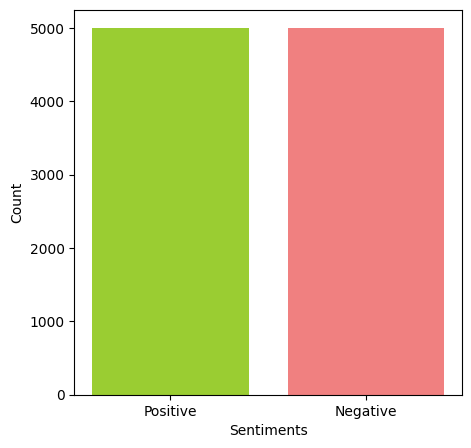

In [ ]:
fig = plt.figure(figsize=(5, 5))

labels = ['Positive', 'Negative']
sizes = [y_positive, y_negative]
colors = ['yellowgreen', 'lightcoral']
plt.bar(labels, sizes, color=colors)
plt.xlabel('Sentiments')
plt.ylabel('Count')
plt.show()

NLP preprosessing

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

In [ ]:
tweet2 = re.sub(r'^RT[\s]+',' ',tweet1["Tweets"])
tweet2= re.sub(r'https?://[^\s\n\r]+', ' ', tweet2)

tweet2 = re.sub(r'#',' ',tweet2)
tweet2 = re.sub(r'@\w+',' ', tweet2)
tweet2 = re.sub(r'[:)| (:]', ' ', tweet2)
print(tweet1["Tweets"])
print("\n Cleaned Tweet: \n", tweet2)

@MyriadPhoto  thanks for retweeting @madsenjewellery orchard art show, have a super weekend :)

 Cleaned Tweet: 
    thanks for retweeting   orchard art show, have a super weekend   


Tokenization

In [ ]:
tokenizer = TweetTokenizer(preserve_case=False, strip_handles= True, reduce_len=True)

tweet_tokens = tokenizer.tokenize(tweet2)

print()
print('Toeknized String:\n')
print(tweet_tokens)


Toeknized String:

['thanks', 'for', 'retweeting', 'orchard', 'art', 'show', ',', 'have', 'a', 'super', 'weekend']


In [ ]:
stopwords_english = stopwords.words('english')

print('stop words \n')
print(stopwords_english)

print('\nPunctuation\n')
print(string.punctuation)

stop words 

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "

In [ ]:
print()
print('\033[92m')
print(tweet_tokens)
print('\033[94m')

tweets_clean=  []

for word in tweet_tokens:
  if (word not in stopwords_english and word not in string.punctuation):
    tweets_clean.append(word)

print('removed stop words and punctuations :')
print(tweets_clean)



['thanks', 'for', 'retweeting', 'orchard', 'art', 'show', ',', 'have', 'a', 'super', 'weekend']

removed stop words and punctuations :
['thanks', 'retweeting', 'orchard', 'art', 'show', 'super', 'weekend']


In [ ]:
def process_tweet(tweet):
  tokenizer = TweetTokenizer(preserve_case=False, strip_handles= True, reduce_len=True)
  # The input 'tweet' is already a string when called with .apply(), so no need to index.
  tweet = re.sub(r'^RT[\s]+',' ',tweet)
  tweet= re.sub(r'https?://[^\s\n\r]+', ' ', tweet)
  tweet = re.sub(r'#',' ',tweet)
  tweet = re.sub(r'@\w+',' ', tweet)
  tweet = re.sub(r'[:)| (:]', ' ', tweet)

  tweet_tokens1 = tokenizer.tokenize(tweet)
  stopwords_english= stopwords.words('english')
  tweet_clean= []

  for word in tweet_tokens1 :
    if (word not in stopwords_english and word not in string.punctuation):
      tweet_clean.append(word)
  return tweet_clean

In [ ]:
final_dataset.head()

,Tweets,Sentiments
0,"I love you, how but you? @Taecyeon2pm8 did you...",negative
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_...,positive
2,"Your love, O Lord, is better than life. :) &lt...",positive
3,@yasminyasir96 yeah but it will be better if w...,positive
4,Ok good night I wish troye wasn't ugly and I m...,positive


In [ ]:
final_dataset.head()

,Tweets,Sentiments
0,"I love you, how but you? @Taecyeon2pm8 did you...",negative
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_...,positive
2,"Your love, O Lord, is better than life. :) &lt...",positive
3,@yasminyasir96 yeah but it will be better if w...,positive
4,Ok good night I wish troye wasn't ugly and I m...,positive


In [ ]:
tweet4= final_dataset.iloc[100]
tweet= tweet4["Tweets"]
process_tweet(tweet)

['achieving',
 'excellence',
 'music',
 'music',
 'producer',
 'mind',
 'boggling',
 'fatiguing',
 'job',
 '...',
 'baareeq',
 '...']

In [ ]:
processed_tweets= final_dataset['Tweets'].apply(process_tweet)
final_dataset['Tweets_processed'] = processed_tweets
pd.set_option('display.max_colwidth', None)
final_dataset

,Tweets,Sentiments,Tweets_processed
0,"I love you, how but you? @Taecyeon2pm8 did you feel the same? Emm I think not :(",negative,"[love, feel, emm, think]"
1,@mayusushita @dildeewana_ @sonalp2591 @deepti_ahmd @armansushita8 Thanks Guys :),positive,"[thanks, guys]"
2,"Your love, O Lord, is better than life. :) &lt;3 https://t.co/KPCeYJqKLM",positive,"[love, lord, better, life, <3]"
3,@yasminyasir96 yeah but it will be better if we use her official Account :) Like The Other @PracchiNDesai ❤️,positive,"[yeah, better, use, official, account, like, ❤, ️]"
4,Ok good night I wish troye wasn't ugly and I met him today:)():)!:!; but ok today was fun I'm excited for tmrw!!,positive,"[ok, good, night, wish, troye, ugly, met, today, ok, today, fun, excited, tmrw]"
...,...,...,...
9995,My nose and forehead are peeling :(,negative,"[nose, forehead, peeling]"
9996,@LittleMix come to Belgium :(,negative,"[come, belgium]"
9997,WHY MUST THE VIDEO STOP THO :(,negative,"[must, video, stop, tho]"
9998,@jeremygutsche we like this amazing donut recipe! we share with #foiegras lovers! :),positive,"[like, amazing, donut, recipe, share, foiegras, lovers]"
